In [3]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [4]:
dataset_path = "Event_occurrence_matrix.csv"

df = pd.read_csv(dataset_path)

print("Shape:", df.shape)

df.head()

Shape: (575061, 32)


,BlockId,Label,Type,E1,E2,E3,E4,E5,E6,E7,...,E20,E21,E22,E23,E24,E25,E26,E27,E28,E29
0,blk_-1608999687919862906,Success,NaN,0,0,203,0,10,7,0,...,0,10,1,10,0,4,10,0,0,0
1,blk_7503483334202473044,Success,NaN,0,2,1,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
2,blk_-3544583377289625738,Fail,21.0,0,0,203,0,3,0,0,...,1,3,1,3,0,0,3,0,0,0
3,blk_-9073992586687739851,Success,NaN,0,3,0,0,3,0,0,...,0,3,1,3,0,0,3,0,0,0
4,blk_7854771516489510256,Success,NaN,0,3,1,15,3,0,0,...,0,3,1,3,0,0,3,0,0,0


In [5]:
print(df["Label"].value_counts())

Label
Success    558223
Fail        16838
Name: count, dtype: int64


In [6]:
sample_size = 100000

if len(df) > sample_size:
    df = df.sample(
        n=sample_size,
        random_state=42
    )

print(df.shape)

(100000, 32)


In [7]:
df["target"] = df["Label"].map({
    "Success": 0,
    "Fail": 1
})

In [8]:
print(df["target"].value_counts())

target
0    97113
1     2887
Name: count, dtype: int64


In [9]:
feature_columns = [
    col for col in df.columns
    if col.startswith("E")
]

print(feature_columns)

['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29']


In [10]:
X = df[feature_columns]

y = df["target"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

model.fit(X_train)

IsolationForest(contamination=0.03, n_estimators=200, random_state=42)

In [13]:
pred = model.predict(X_test)

pred = np.where(
    pred == -1,
    1,
    0
)

In [14]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19454
           1       0.76      0.59      0.67       546

    accuracy                           0.98     20000
   macro avg       0.88      0.79      0.83     20000
weighted avg       0.98      0.98      0.98     20000



In [15]:
accuracy = accuracy_score(
    y_test,
    pred
)

print("Accuracy:", accuracy)

Accuracy: 0.98385


In [16]:
cm = confusion_matrix(
    y_test,
    pred
)

print(cm)

[[19354   100]
 [  223   323]]


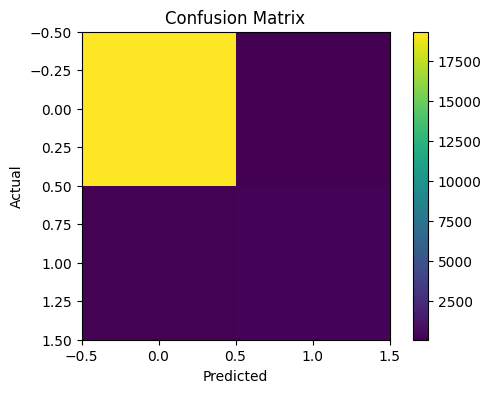

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.imshow(cm)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
joblib.dump(
    model,
    "metricguard_log_model.pkl"
)

print("Model Saved")

Model Saved


In [19]:
model = joblib.load(
    "metricguard_log_model.pkl"
)

In [20]:
def predict_log(features):

    features = np.array(features).reshape(1, -1)

    prediction = model.predict(features)[0]

    if prediction == -1:
        return "ANOMALY"

    return "NORMAL"

In [21]:
sample = X_test.iloc[0].tolist()

predict_log(sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


'NORMAL'

In [22]:
def anomaly_score(features):

    features = np.array(features).reshape(1, -1)

    return model.decision_function(features)[0]

In [23]:
score = anomaly_score(
    X_test.iloc[0].tolist()
)

print(score)

0.29464807636126983


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
